## SARIMAX stands for Seasonal AutoRegressive Integrated Moving Average with eXogenous variables.

Here’s a simple and detailed explanation:

## What is SARIMAX?
- SARIMAX is a time series forecasting model.
- It is an advanced version of ARIMA that can:

- Handle seasonal patterns in your data (like daily, weekly, or yearly cycles).
- Use extra features (called exogenous variables), such as weather, battery health, or any other information that might affect your target.
## Breaking down the name:
- S: Seasonal — It can model repeating patterns (like higher charging in summer).
- AR: AutoRegressive — Uses past values to predict the future.
- I: Integrated — Makes the data more stable by differencing (subtracting previous values).
- MA: Moving Average — Uses past errors to improve predictions.
- X: Exogenous — Allows you to add other variables (features) that help with prediction.
## Why use SARIMAX?
- If your data has seasonal trends (like more charging on weekends), SARIMAX can model that.
- If you have other features (like temperature, charger type, etc.), SARIMAX can use them to make better predictions.
- It is more powerful than ARIMA for real-world problems where many factors affect the target.
## Example
- Suppose you want to predict charging duration for electric vehicles:

- Target: Charging duration (what you want to predict)
- Exogenous variables: Battery size, weather, charger type, time of day, etc.
### SARIMAX will use both the past charging durations and all these extra features to make a more accurate forecast.

## In summary:
- SARIMAX is a flexible and powerful time series model that can handle both seasonality and extra features, making it very useful for complex forecasting problems like yours.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
! pip install statsmodels

  Using cached statsmodels-0.14.5-cp311-cp311-win_amd64.whl.metadata (9.8 kB)
  Using cached patsy-1.0.1-py2.py3-none-any.whl.metadata (3.3 kB)
Using cached statsmodels-0.14.5-cp311-cp311-win_amd64.whl (9.6 MB)
Using cached patsy-1.0.1-py2.py3-none-any.whl (232 kB)



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


--- Fitting SARIMAX Model ---
SARIMAX model fitting complete.

--- SARIMAX Model Performance ---
Model performance for Training set
- Root Mean Squared Error (RMSE): 28.9436
- Mean Absolute Error (MAE): 14.0929
- R2 Score: 0.8904
----------------------------------
Model performance for Test set
- Root Mean Squared Error (RMSE): 27.8770
- Mean Absolute Error (MAE): 14.2398
- R2 Score: 0.8982


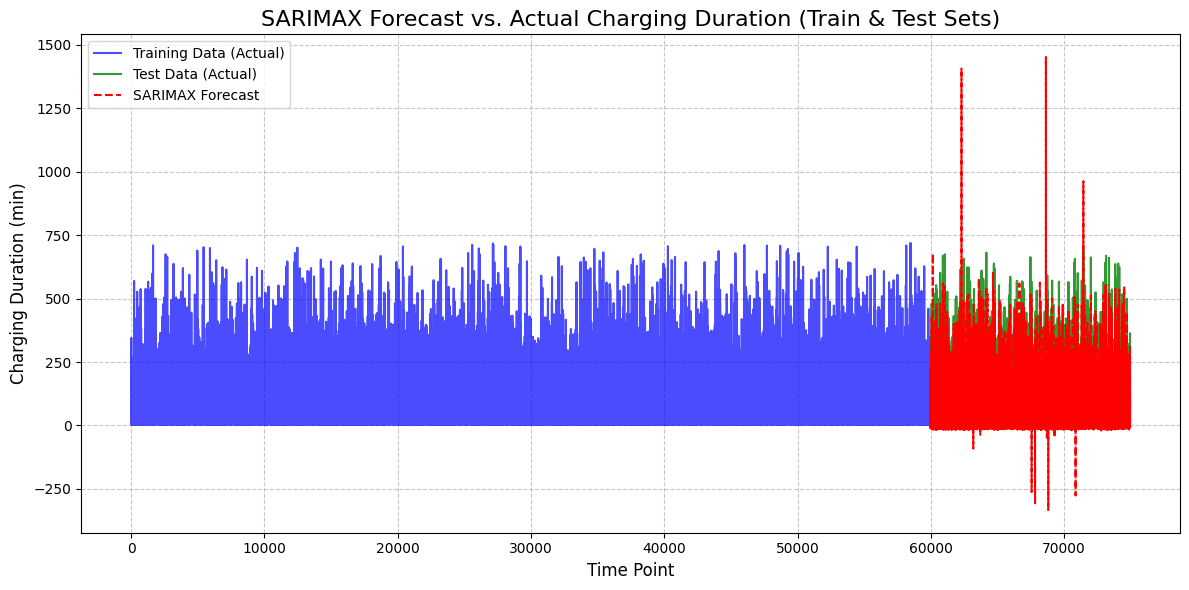

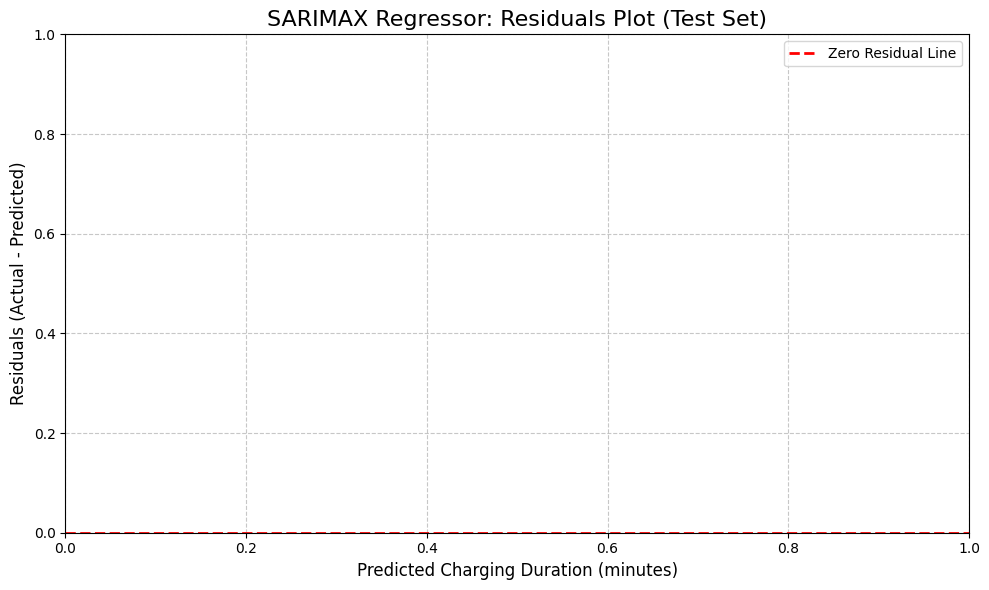

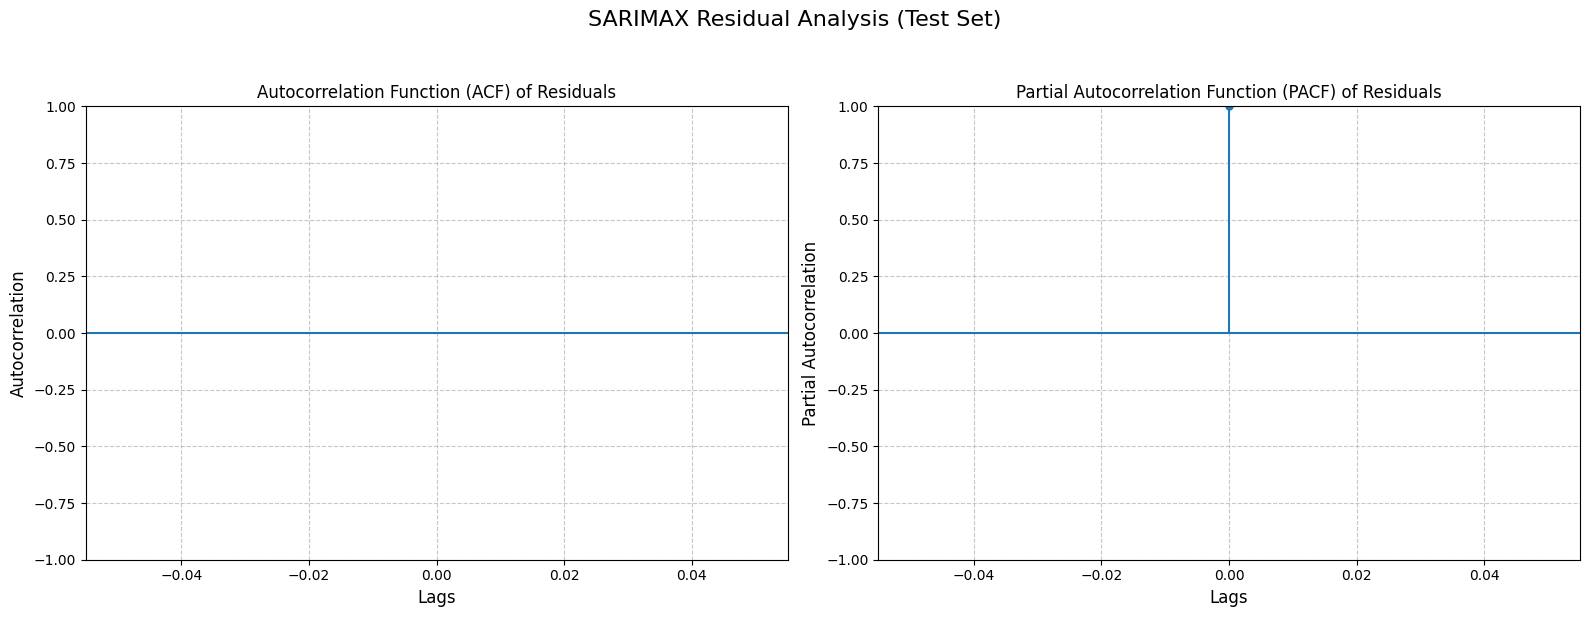


SARIMAX model evaluation complete. Metrics printed and three plots generated.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

# Suppress convergence warnings for cleaner output during execution,
# but remember to address them for final model robustness.
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


# --- 1. Load the Dataset ---
# Ensure X_train.csv, X_test.csv, y_train.csv, y_test.csv are accessible.
try:
    X_train = pd.read_csv(r"../data/X_train.csv")
    X_test = pd.read_csv(r"../data/X_test.csv")
    y_train = pd.read_csv(r"../data/y_train.csv")
    y_test = pd.read_csv(r"../data/y_test.csv")
except FileNotFoundError:
    print("Error: One or more data files (X_train.csv, X_test.csv, y_train.csv, y_test.csv) not found.")
    print("Please ensure your preprocessed and split data files are in the correct directory.")
    exit()

# --- Prepare exogenous variables (features) and target series ---
exog_train = X_train
exog_test = X_test
train_series = y_train['charging_duration_min']
test_series = y_test['charging_duration_min']

# --- 2. Define a function to evaluate model performance ---
def evaluate_model(true, predicted, dataset_name=""):
    mae = mean_absolute_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2 = r2_score(true, predicted)
    print(f"Model performance for {dataset_name} set")
    print(f"- Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"- Mean Absolute Error (MAE): {mae:.4f}")
    print(f"- R2 Score: {r2:.4f}")
    return mae, rmse, r2

# --- 3. Fit SARIMAX model ---
# Using the order and seasonal_order from your provided notebook.
# Note: seasonal_order=(0,0,0,0) means no seasonality is being modeled.
# The ConvergenceWarning might appear, indicating optimization issues.
print("--- Fitting SARIMAX Model ---")
sarimax_model = SARIMAX(train_series, exog=exog_train, order=(1,1,1), seasonal_order=(0,0,0,0))
sarimax_fit = sarimax_model.fit(disp=False)
print("SARIMAX model fitting complete.")

# --- 4. Make Predictions for Training and Test Sets ---
# Predictions on training data (in-sample predictions)
y_train_pred_sarimax = sarimax_fit.predict(start=0, end=len(train_series)-1, exog=exog_train)

# Predictions on test data (out-of-sample forecasts)
y_test_pred_sarimax = sarimax_fit.predict(start=len(train_series),
                                          end=len(train_series) + len(test_series) - 1,
                                          exog=exog_test)

# --- 5. Evaluate the Model for Training and Test Sets ---
print("\n--- SARIMAX Model Performance ---")
train_mae, train_rmse, train_r2 = evaluate_model(train_series, y_train_pred_sarimax, "Training")
print('----------------------------------')
test_mae, test_rmse, test_r2 = evaluate_model(test_series, y_test_pred_sarimax, "Test")
print('='*35)


# --- 6. Plot 1: Actual vs. Predicted Charging Duration (Test Set) ---
plt.figure(figsize=(12, 6))
plt.plot(range(len(train_series)), train_series, label='Training Data (Actual)', color='blue', alpha=0.7)
plt.plot(range(len(train_series), len(train_series) + len(test_series)), test_series.values, label='Test Data (Actual)', color='green', alpha=0.8)
plt.plot(range(len(train_series), len(train_series) + len(test_series)), y_test_pred_sarimax, label='SARIMAX Forecast', color='red', linestyle='--')
plt.title('SARIMAX Forecast vs. Actual Charging Duration (Train & Test Sets)', fontsize=16)
plt.xlabel('Time Point', fontsize=12)
plt.ylabel('Charging Duration (min)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- 7. Plot 2: Residuals Plot (Test Set) ---
residuals_sarimax = test_series - y_test_pred_sarimax

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_pred_sarimax, y=residuals_sarimax, alpha=0.6, color='purple')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Residual Line')
plt.title('SARIMAX Regressor: Residuals Plot (Test Set)', fontsize=16)
plt.xlabel('Predicted Charging Duration (minutes)', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# --- 8. Plot 3: ACF and PACF of Residuals (Test Set) ---
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Ensure residuals are a pandas Series for plotting
residuals_sarimax_series = pd.Series(residuals_sarimax)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_acf(residuals_sarimax_series, ax=axes[0], lags=40, title='Autocorrelation Function (ACF) of Residuals')
axes[0].set_xlabel('Lags', fontsize=12)
axes[0].set_ylabel('Autocorrelation', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)

plot_pacf(residuals_sarimax_series, ax=axes[1], lags=40, title='Partial Autocorrelation Function (PACF) of Residuals')
axes[1].set_xlabel('Lags', fontsize=12)
axes[1].set_ylabel('Partial Autocorrelation', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.suptitle('SARIMAX Residual Analysis (Test Set)', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

print("\nSARIMAX model evaluation complete. Metrics printed and three plots generated.")


In [2]:
X_train = pd.read_csv(r"../data/X_train.csv")
X_test = pd.read_csv(r"../data/X_test.csv")
y_train = pd.read_csv(r"../data/y_train.csv")
y_test = pd.read_csv(r"../data/y_test.csv")

In [3]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((59954, 92), (59954, 1), (14989, 92), (14989, 1))

In [4]:
X_train.shape, y_train.shape,X_test.shape,y_test.shape

((59954, 92), (59954, 1), (14989, 92), (14989, 1))

In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [6]:
# Prepare exogenous variables (features)
exog_train = X_train
exog_test = X_test

In [7]:
# Target variable
train_series = y_train['charging_duration_min']
test_series = y_test['charging_duration_min']

In [8]:
# Fit SARIMAX model (order and seasonal_order can be tuned)
model = SARIMAX(train_series, exog=exog_train, order=(1,1,1), seasonal_order=(0,0,0,0))
model_fit = model.fit(disp=False)

c:\Users\aman2\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [9]:
# Forecast for the length of the test set
forecast = model_fit.predict(start=len(train_series), end=len(train_series)+len(test_series)-1, exog=exog_test)

In [10]:
# Evaluate the model
mse = mean_squared_error(test_series, forecast)
mae = mean_absolute_error(test_series, forecast)
r2 = r2_score(test_series, forecast)

In [11]:
print(f"Test MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test R2 Score: {r2:.2f}")

Test MSE: 777.09
Test MAE: 14.22
Test R2 Score: 0.90


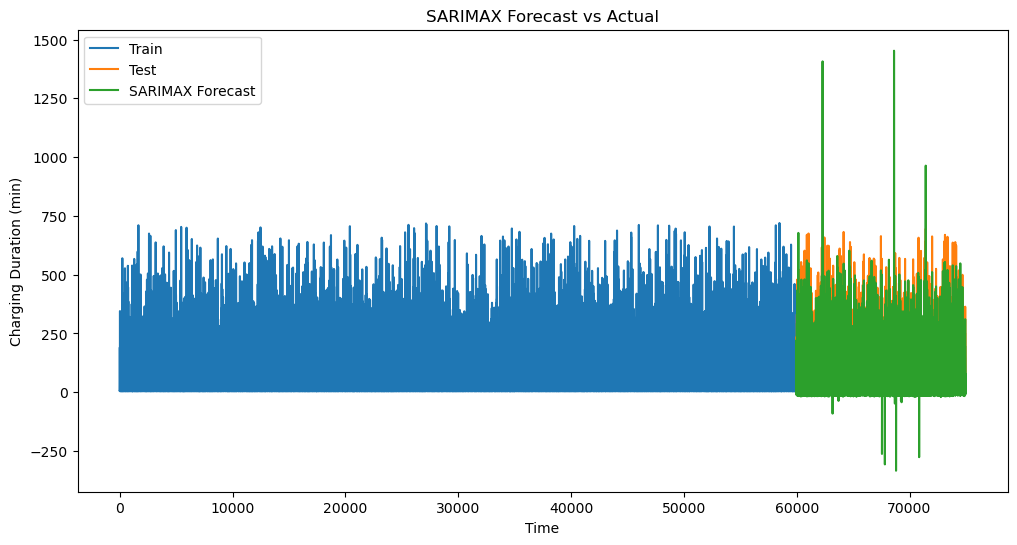

In [12]:
# Visualization: Plot actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(range(len(train_series)), train_series, label='Train')
plt.plot(range(len(train_series), len(train_series)+len(test_series)), test_series.values, label='Test')
plt.plot(range(len(train_series), len(train_series)+len(test_series)), forecast, label='SARIMAX Forecast')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Charging Duration (min)')
plt.title('SARIMAX Forecast vs Actual')
plt.show()

In [ ]:
# # import warnings
# from statsmodels.tsa.statespace.sarimax import SARIMAX
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# # warnings.filterwarnings("ignore")

# best_score = float('inf')
# best_order = None
# best_seasonal_order = None

# # Define ranges for p, d, q and seasonal parameters (P, D, Q, s)
# for p in range(0, 3):
#     for d in range(0, 2):
#         for q in range(0, 3):
#             for P in range(0, 2):
#                 for D in range(0, 2):
#                     for Q in range(0, 2):
#                         for s in [0, 4, 7, 12]:  # Try no seasonality, weekly, and yearly
#                             try:
#                                 model = SARIMAX(
#                                     y_train['charging_duration_min'],
#                                     exog=X_train,
#                                     order=(p, d, q),
#                                     seasonal_order=(P, D, Q, s)
#                                 )
#                                 model_fit = model.fit(disp=False)
#                                 forecast = model_fit.predict(
#                                     start=len(y_train),
#                                     end=len(y_train)+len(y_test)-1,
#                                     exog=X_test
#                                 )
#                                 mse = mean_squared_error(y_test['charging_duration_min'], forecast)
#                                 if mse < best_score:
#                                     best_score = mse
#                                     best_order = (p, d, q)
#                                     best_seasonal_order = (P, D, Q, s)
#                             except:
#                                 continue

# print(f"Best SARIMAX order: {best_order} seasonal_order: {best_seasonal_order} with Test MSE: {best_score:.2f}")

# # Fit and evaluate the best model
# model = SARIMAX(
#     y_train['charging_duration_min'],
#     exog=X_train,
#     order=best_order,
#     seasonal_order=best_seasonal_order
# )
# model_fit = model.fit(disp=False)
# forecast = model_fit.predict(
#     start=len(y_train),
#     end=len(y_train)+len(y_test)-1,
#     exog=X_test
# )

# mse = mean_squared_error(y_test['charging_duration_min'], forecast)
# mae = mean_absolute_error(y_test['charging_duration_min'], forecast)
# r2 = r2_score(y_test['charging_duration_min'], forecast)

# print(f"Test MSE: {mse:.2f}")
# print(f"Test MAE: {mae:.2f}")
# print(f"Test R2 Score: {r2:.2f}")

# # Visualization
# plt.figure(figsize=(12,6))
# plt.plot(range(len(y_train)), y_train['charging_duration_min'], label='Train')
# plt.plot(range(len(y_train), len(y_train)+len(y_test)), y_test['charging_duration_min'].values, label='Test')
# plt.plot(range(len(y_train), len(y_train)+len(y_test)), forecast, label='SARIMAX Forecast')
# plt.legend()
# plt.xlabel('Time')
# plt.ylabel('Charging Duration (min)')
# plt.title('SARIMAX Forecast vs Actual (Best Order)')
# plt.show()